# Relatório Técnico – Tarefa 3: Aquisição, Processamento e Visualização de Dados

**Unidade Curricular:** Física Aplicada à Computação  
**Ano Letivo:** 2025/2026  
**Instituto:** IPBeja – Licenciatura em Engenharia Informática
**Integrantes do grupo:**
- Victor de paula;


---

## Introdução

Este relatório documenta o trabalho realizado nas Tarefas 1, 2 e 3, que consistem na implementação de um sistema completo de aquisição, processamento e visualização de dados de sensores integrados numa placa de microcontrolador. 

O objetivo global é combinar:
- Leitura simultânea de múltiplos sensores no hardware
- Transmissão de dados em tempo real para a nuvem
- Processamento local e análise estatística

O projeto foi desenvolvido de forma incremental, começando pela aquisição simples de dados (T1), passando pela integração em plataforma cloud (T2), e finalizando com análise detalhada e exportação estruturada de resultados (T3).


## Hardware Utilizado

### Arduino Nano RP2040 Connect

**Especificações principais:**
- **Processador:** RP2040 (dual-core ARM Cortex-M0+, 133 MHz)
- **Memória RAM:** 264 KB
- **Flash:** 16 MB
- **Conectividade:** WiFi integrada
- **Interface de comunicação:** USB nativo (CDC)

### Sensores Integrados

#### IMU LSM6DSOX
- **Acelerómetro:** 3 eixos (±16 g), resolução 16 bits
  - Mede: ax, ay, az (em unidades de g)
- **Giroscópio:** 3 eixos (±2000 deg/s), resolução 16 bits
  - Mede: gx, gy, gz (em deg/s)
- **Temperatura:** -40 °C a +85 °C

#### Microfone PDM (MP34DT06J)
- **Amostragem:** 16 kHz
- **Gama:** 20 a 120 dB SPL
- **Parâmetros:** soundRMS (nível médio), soundPeak (amplitude máxima)

### Resumo de Parâmetros
O sistema recolhe **9 parâmetros por leitura:**
- 3 componentes de aceleração (ax, ay, az)
- 3 componentes de velocidade angular (gx, gy, gz)
- 1 temperatura (temp)
- 2 indicadores de som (soundRMS, soundPeak)

Calcula-se também a **magnitude da aceleração total:** accelTotal = √(ax² + ay² + az²)


## Tarefa 1: Aquisição de Dados de Sensores

### Objetivo e Implementação

A Tarefa 1 desenvolveu um sketch modular para leitura simultânea de todos os sensores, com filtro de média móvel e timestamps relativos (millis()).

**Características principais:**
- Leitura simultânea da IMU e microfone
- Filtro por média móvel simples (buffer circular configurável)
- Timestamps relativos (milissegundos desde arranque)
- Múltiplos modos de visualização (Serial Monitor / Plotter)

**Estrutura do código:**
- `lab01_sensores.ino` – ficheiro principal
- `header.h` – bibliotecas e constantes
- `types.h` – estruturas de dados
- `functions.h/cpp` – funções genéricas
- `sensor_imu.h/cpp` – funções da IMU
- `sensor_mic.h/cpp` – funções do microfone

A filtragem por média móvel reduz ruído sem introduzir atraso significativo, aplicando: `avg[i] = (soma dos últimos N samples) / N`

**Validação:** Dados coerentes com movimentos físicos; temperatura estável; compilação sem erros.


### Explicação do Código T1

**Estrutura do sketch:**

1. **Inclusão de bibliotecas:** IMU LSM6DSOX, PDM (microfone), cálculos matemáticos

2. **Inicialização (setup):**
   - Inicia porta série a 115200 baud
   - Inicializa IMU com frequência de amostragem ~100 Hz
   - Inicializa microfone PDM

3. **Loop principal:**
   - A cada 100 ms, lê aceleração, giroscópio e temperatura
   - Aplica filtro de média móvel a cada parâmetro
   - Calcula magnitude da aceleração
   - Imprime valores em Serial Monitor ou Plotter

4. **Funções auxiliares:**
   - `average()` – calcula média móvel com buffer circular
   - `printValues()` – formata saída para Serial Monitor
   - `printPlotter()` – formata saída para Serial Plotter (CSV)

Este sketch estabelece a base para as Tarefas seguintes.


## Tarefa 2: Arduino Cloud – Monitorização em Tempo Real

### Objetivo e Implementação

A Tarefa 2 estendeu o código da T1 adicionando conectividade WiFi e integração com Arduino Cloud, permitindo monitorização remota e alertas automáticos.

**Novas funcionalidades:**
- Ligação WiFi automática
- Sincronização com Arduino Cloud
- Dashboard interativo com 5 variáveis cloud
- Alertas visuais (LED) quando temp > 35°C ou som > 2000

**Variáveis Cloud:**
- `sensorAccel` (float) – aceleração total média
- `sensorSound` (float) – nível de som RMS
- `sensorTemp` (float) – temperatura média
- `timestampSec` (float) – tempo em segundos
- `ledControl` (bool) – controlo manual do LED

**Fluxo de dados:**

Arduino → WiFi → Arduino Cloud → Dashboard (browser)

↓

(gráficos em tempo real)



A Cloud oferece sincronização em tempo real (~200 ms), histórico de 30 dias e acesso remoto.


### Explicação do Código T2

**Adições ao sketch original:**

1. **Bibliotecas Arduino Cloud:**
   - `ArduinoIoTCloud.h` – sincronização cloud
   - `Arduino_ConnectionHandler.h` – gestão WiFi

2. **Definição de variáveis cloud:**
   - Cada variável é sincronizada bidireccionalmente
   - Callbacks permitem reação a mudanças

3. **Função initProperties():**
   - Mapeia variáveis Arduino às propriedades cloud
   - Define permissões (READ / READ_WRITE)

4. **Função onLedControlChange():**
   - Callback disparada quando `ledControl` muda na cloud
   - Atualiza LED físico (GPIO LEDB)

5. **Loop principal:**
   - Mantém a mesma lógica de leitura de sensores
   - Adicionalmente, atualiza variáveis cloud a cada ciclo
   - Lógica de alertas: se `temp > 35 OR sound > 500`, liga LED

Este código permite monitorização remota enquanto mantém toda a funcionalidade local da T1.


## Dashboard Arduino Cloud

### Estrutura e Widgets

O dashboard foi construído com múltiplos widgets para visualização efetiva:

#### **Gráficos Temporais (Coluna Esquerda)**

1. **Aceleração Total (g)**
   - Linha chart com histórico 24h
   - Escala automática (típica: 0.8 a 1.2 g em repouso, até 2 g em movimento)
   - ~1 g em repouso corresponde à gravidade

2. **Som RMS**
   - Linha chart com histórico 24h
   - Valores baixos (<100) = silêncio
   - Valores médios (100-300) = conversação
   - Picos (>500) = ruído significativo

3. **Temperatura (°C)**
   - Linha chart com histórico 24h
   - Típica 14-16 °C em ambiente controlado
   - Pode subir com funcionamento prolongado

#### **Mostradores Instantâneos (Coluna Direita)**

- **Aceleração, Som, Temperatura:** gauges circulares com valor numérico
- **Tempo:** display retangular em segundos
- Permitem "leitura rápida" sem interpretar gráficos

#### **Controlo**

- **Switch do LED:** toggle manual ou automático (alertas)
- **Indicador visual do LED:** confirmação do estado físico

#### **Mapa**

- Localização geográfica do Arduino
- Contexto para monitorização distribuída


![Dashboard Arduino Cloud](./imagem%20do%20dashboard.png)


## Tarefa 3: Processamento Avançado em Python

### Objetivo

A Tarefa 3 completa o ciclo com análise offline em Python, adicionando timestamps absolutos via NTP e estatística descritiva detalhada.

### Extensão do Hardware: Timestamp NTP

A T3 adiciona sincronização com servidor NTP para obter **timestamps absolutos** (YYYY-MM-DD HH:MM:SS) em vez de relativos (millis()).

**Por quê?**
- T1 e T2 usam `millis()`: tempo desde arranque (útil para durações)
- T3 precisa de hora real: permite correlacionar com eventos externos e análise histórica

**Implementação:**
- Biblioteca: `NTPClient`
- Servidor: `pool.ntp.org`
- Cada leitura é etiquetada com timestamp absoluto

### Formato de Transmissão Serial

Cada linha segue o formato:
YYYY-MM-DD HH:MM:SS;accelTotal;ax;ay;az;gx;gy;gz;temp;soundRMS


Exemplo:
2026-01-29 01:38:37;0.995;-0.006;-0.764;0.638;0.122;0.305;-0.183;32.000;55.657


Este formato é **legível, estruturado (`;`-separado) e completo**.

### Análise em Python

A análise inclui:

1. **Leitura e validação** de dados via porta série
2. **Estatística descritiva:** mín, máx, média, mediana, desvio padrão
3. **Visualização:** gráficos temporais com referências (mín, máx, média, mediana)
4. **Deteção de alertas:** baseada em limites (aceleração > 1.5 g, som > 500 RMS)
5. **Exportação:** dados, estatística e meta-informação para Excel

**Fluxo completo:**
Arduino (porta série) → Python (DataFrame) → Análise → Excel
→ Gráficos

In [3]:
import serial
import time
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

PORT = "COM6"      # porta correta do teu Arduino
BAUDRATE = 115200
NUM_READS = 50    # número de leituras a adquirir

ACCEL_LIMIT = 1.5      # limite de aceleração total (g)
SOUND_LIMIT = 500.0   # limite de som RMS


### Setup e Configuração

- **PORT:** porta série onde Arduino está conectado (COM6 neste caso, verificar em Arduino IDE)
- **BAUDRATE:** 115200 para compatibilidade com Arduino Nano RP2040
- **NUM_READS:** quantidade de leituras a recolher (10 neste exemplo, aumentar conforme necessário)
- **Limites de alerta:**
  - Aceleração 1.5 g: 50% acima do repouso (1 g), indica movimento/vibração
  - Som 500 RMS: significativamente acima do ambiente normal (<100)

`plt.style.use("seaborn-v0_8")` - aplica estilo visual aos gráficos


In [6]:
lines = []

with serial.Serial(PORT, BAUDRATE, timeout=1) as ser:
    time.sleep(2)  # tempo para o Arduino reiniciar
    print("A adquirir dados do Arduino...")
    while len(lines) < NUM_READS:
        raw_line = ser.readline().decode("utf-8", errors="ignore").strip()
        if not raw_line:
            continue
        parts = raw_line.split(";")
        if len(parts) != 10:
            # print("Linha ignorada:", raw_line)
            continue
        lines.append(parts)

print(f"Número de linhas válidas adquiridas: {len(lines)}")

columns = ["timestamp_str", "accelTotal", "ax", "ay", "az",
           "gx", "gy", "gz", "temp", "soundRMS"]

df = pd.DataFrame(lines, columns=columns)

df["timestamp"] = pd.to_datetime(df["timestamp_str"],
                                 format="%Y-%m-%d %H:%M:%S",
                                 errors="coerce")

for col in ["accelTotal", "ax", "ay", "az", "gx", "gy", "gz", "temp", "soundRMS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["timestamp"]).reset_index(drop=True)
df.head()


A adquirir dados do Arduino...
Número de linhas válidas adquiridas: 50


,timestamp_str,accelTotal,ax,ay,az,gx,gy,gz,temp,soundRMS,timestamp
0,2026-01-29 11:27:54,0.985,0.006,-0.179,0.969,-83.069,60.486,-30.762,24.333,97.144,2026-01-29 11:27:54
1,2026-01-29 11:27:54,0.995,0.004,-0.195,0.975,137.024,2.563,0.610,24.500,97.167,2026-01-29 11:27:54
2,2026-01-29 11:27:56,0.996,0.004,-0.211,0.974,-8.667,0.427,-0.061,24.600,134.658,2026-01-29 11:27:56
3,2026-01-29 11:27:56,0.997,0.004,-0.222,0.972,-2.441,0.305,-0.244,24.667,126.560,2026-01-29 11:27:56
4,2026-01-29 11:27:57,0.997,0.004,-0.230,0.970,1.038,0.305,-0.305,24.714,126.587,2026-01-29 11:27:57


### Função de Leitura da Porta Série

O código:
1. Abre a porta série com timeout de 1 segundo
2. Aguarda 2 segundos para inicialização do Arduino (reset automático)
3. Lê linhas continuamente até atingir NUM_READS leituras válidas
4. Valida cada linha:
   - Deve conter exatamente 10 campos (separados por `;`)
   - Ignora linhas incompletas ou malformadas
5. Armazena cada linha válida numa lista

Resultado: `lines` contém NUM_READS linhas válidas, prontas para processamento



### Criação e Validação do DataFrame

1. **Estrutura de colunas:** 10 campos (timestamp string + 9 sensores)

2. **Conversão de timestamp:**
   - Formato entrada: "YYYY-MM-DD HH:MM:SS"
   - Formato saída: datetime (permite operações de tempo e plotagem)

3. **Conversão numérica:** todos os 9 parâmetros de sensor convertidos para float

4. **Limpeza:** remove linhas com valores inválidos ou timestamp mal formado

5. **Reset de índice:** reindexação sequencial (0, 1, 2, ..., N-1)

Resultado: `df` é um DataFrame pandas limpo e pronto para análise


In [7]:
sensor_cols = ["accelTotal", "ax", "ay", "az",
               "gx", "gy", "gz", "temp", "soundRMS"]

stats = df[sensor_cols].describe().T
stats_table = stats[["min", "mean", "50%", "max", "std"]].copy()
stats_table.rename(columns={"50%": "median"}, inplace=True)
stats_table


,min,mean,median,max,std
accelTotal,0.985,0.99998,1.001,1.004,0.002722
ax,0.003,0.00400,0.003,0.023,0.003488
ay,-0.277,-0.26204,-0.268,-0.179,0.021004
az,0.961,0.96492,0.964,0.975,0.002934
gx,-83.069,1.81138,0.305,137.024,23.097930
gy,0.183,1.53426,0.305,60.486,8.513359
gz,-30.762,-0.87144,-0.305,0.610,4.315527
temp,24.333,25.29084,25.200,26.000,0.470561
soundRMS,90.298,205.44044,134.156,542.701,139.468091


### Estatística Descritiva

O método `describe()` calcula automaticamente:
- **min:** valor mínimo
- **mean:** média aritmética
- **50%:** percentil 50% (mediana)
- **max:** valor máximo
- **std:** desvio padrão (dispersão)

A coluna "50%" é renomeada para "median" para clareza.

Resultado: tabela com uma linha por sensor e 5 colunas de estatísticas


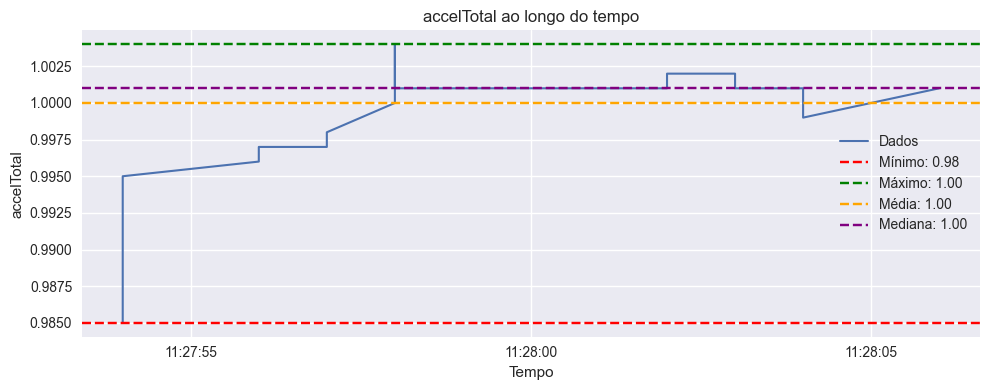

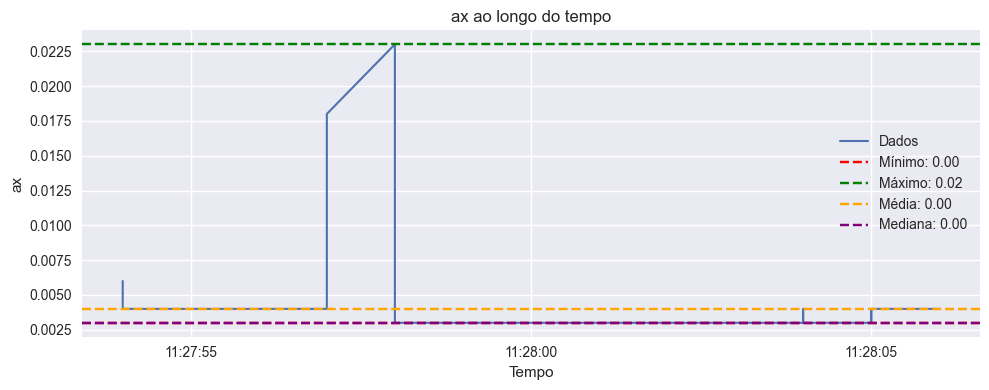

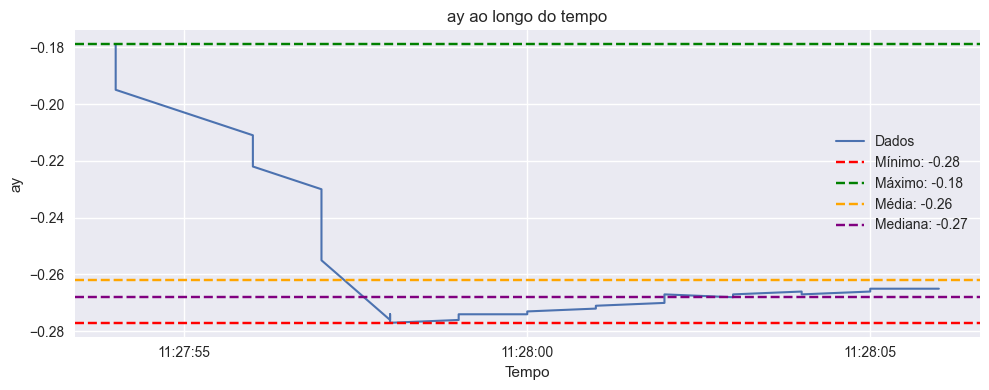

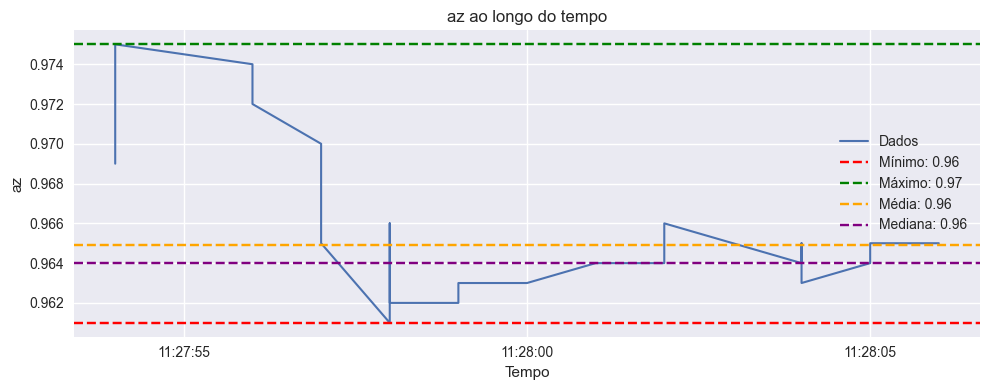

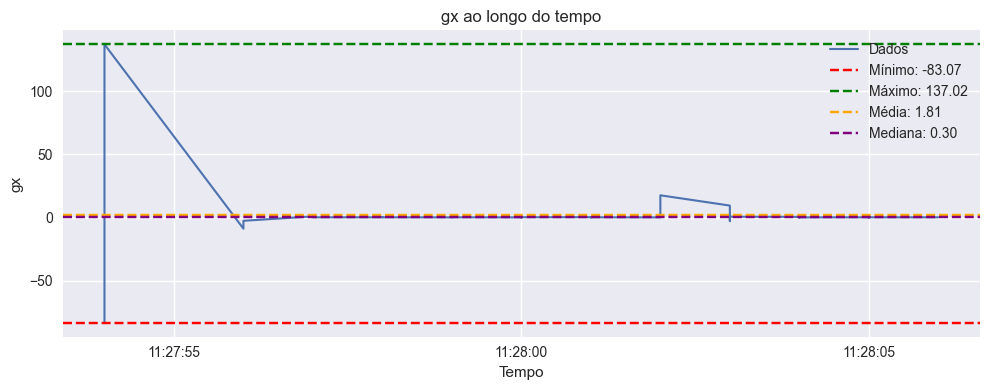

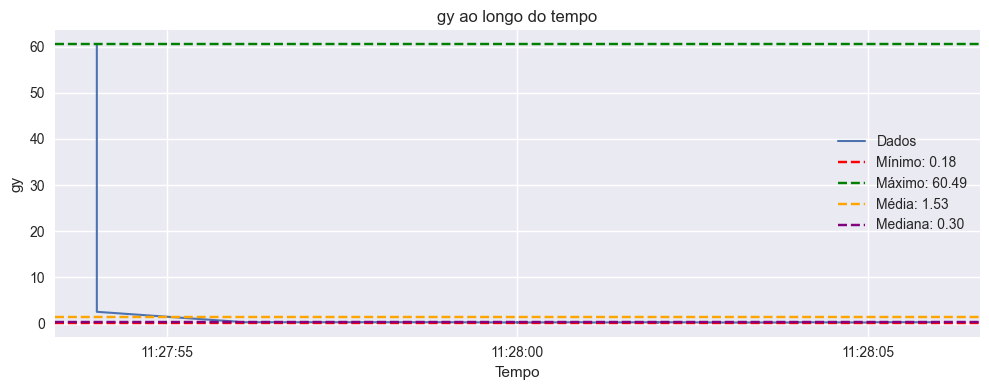

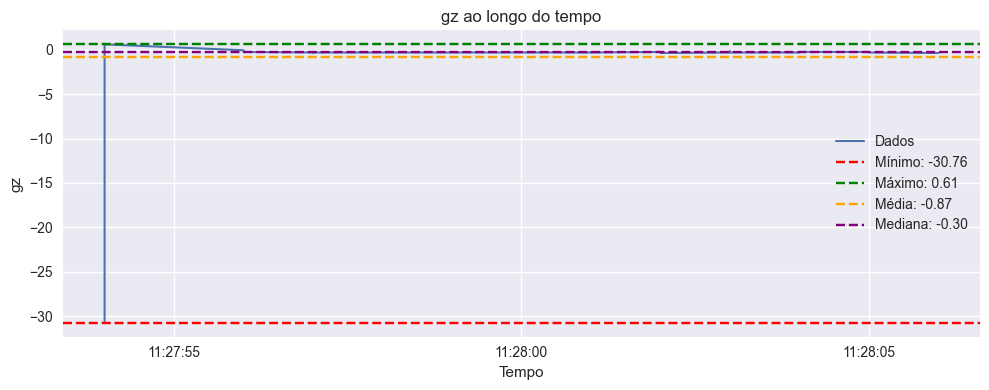

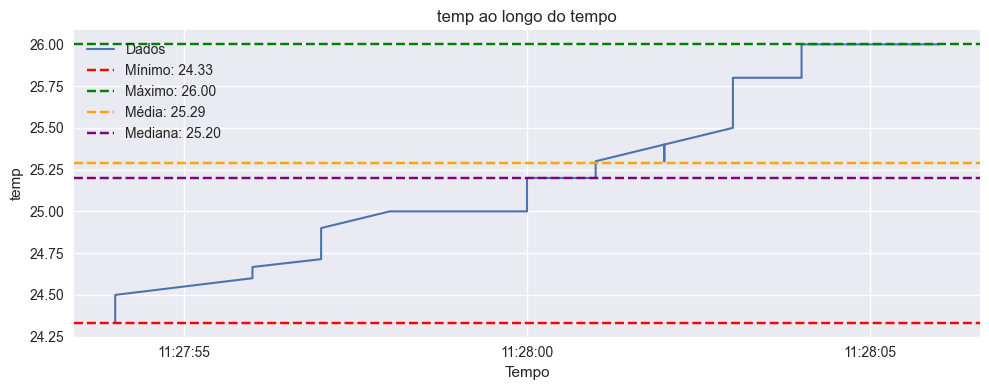

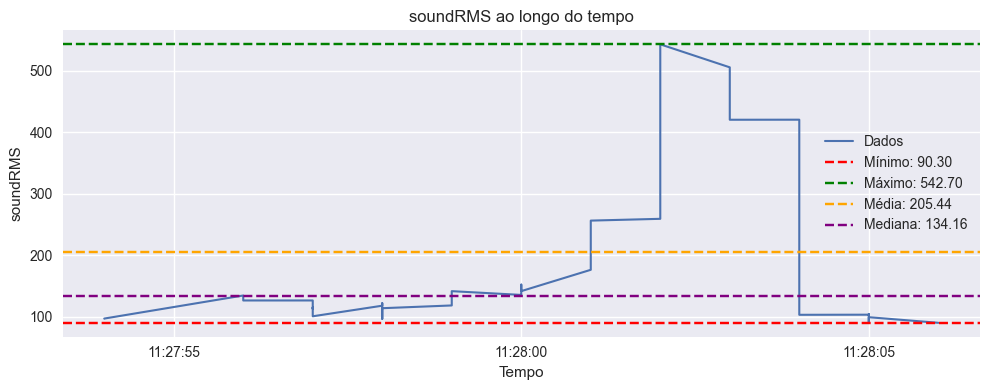

In [8]:
for col in sensor_cols:
    plt.figure(figsize=(10, 4))
    plt.plot(df["timestamp"], df[col], label="Dados", linewidth=1.5)

    min_val = df[col].min()
    max_val = df[col].max()
    mean_val = df[col].mean()
    median_val = df[col].median()

    plt.axhline(y=min_val, color="red", linestyle="--",
                label=f"Mínimo: {min_val:.2f}")
    plt.axhline(y=max_val, color="green", linestyle="--",
                label=f"Máximo: {max_val:.2f}")
    plt.axhline(y=mean_val, color="orange", linestyle="--",
                label=f"Média: {mean_val:.2f}")
    plt.axhline(y=median_val, color="purple", linestyle="--",
                label=f"Mediana: {median_val:.2f}")

    plt.title(f"{col} ao longo do tempo")
    plt.xlabel("Tempo")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Visualização com Anotações

Para cada um dos 9 sensores, desenha um gráfico:

**Componentes do gráfico:**
- **Linha contínua azul:** dados brutos ao longo do tempo
- **Linha tracejada vermelha:** mínimo (limite inferior)
- **Linha tracejada verde:** máximo (limite superior)
- **Linha tracejada laranja:** média (tendência central)
- **Linha tracejada roxa:** mediana (valor central)

**Interpretação:**
- Distância entre vermelho e verde = intervalo de variação
- Proximidade entre laranja e roxa = simetria da distribuição
- Picos acima/abaixo = outliers
- Padrões visuais = comportamentos periódicos ou anómalos

Exemplo: aceleração em repouso mostra ~1g constante (gravidade), com picos quando há movimento


In [9]:
def check_alerts(df, col, limit):
    mask = df[col] > limit
    return df.loc[mask, ["timestamp", col]].copy()

alerts_accel = check_alerts(df, "accelTotal", ACCEL_LIMIT)
alerts_sound = check_alerts(df, "soundRMS", SOUND_LIMIT)

print("=== Alertas de aceleração total ===")
display(alerts_accel)

print("\n=== Alertas de som RMS ===")
display(alerts_sound)

print(f"\nN.º alertas aceleração: {len(alerts_accel)}")
print(f"N.º alertas som: {len(alerts_sound)}")


=== Alertas de aceleração total ===


,timestamp,accelTotal



=== Alertas de som RMS ===


,timestamp,soundRMS
32,2026-01-29 11:28:02,524.966
33,2026-01-29 11:28:02,542.701
34,2026-01-29 11:28:03,505.322



N.º alertas aceleração: 0
N.º alertas som: 3


### Deteção de Alertas

A função `check_alerts()` filtra linhas onde um valor ultrapassa um limite:

**Parâmetros:**
- `df` – DataFrame com todos os dados
- `col` – coluna a verificar (ex: "accelTotal")
- `limit` – limite máximo permitido

**Retorna:** tabela com timestamp e valor para todas as ocorrências > limite

**Alertas calculados:**
1. **Aceleração total > 1.5 g** (50% acima do repouso)
   - Indica movimento/vibração significativa
   - Útil para detetar impactos ou agitação

2. **Som RMS > 500** (muito acima do normal)
   - Indica evento sonoro relevante
   - Validado: bater palmas ultrapassa este limite

**Output:**
- Tabela com instantes exatos de alerta
- Contagem total de ocorrências

Permite correlacionar alertas com eventos externos e implementar reações automáticas


In [10]:
from openpyxl import Workbook  # garantido pelo openpyxl

output_filename = "dados_fisica_lab3.xlsx"

duracao_seg = (df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]).total_seconds()

meta_data = {
    "Campo": [
        "Origem dos dados",
        "Modelo Arduino",
        "Sensores",
        "Descrição dos sensores",
        "Número total de leituras",
        "Duração total (segundos)",
        "Data/Hora de início",
        "Data/Hora de fim",
        "",
        "Limite de alerta - Aceleração (g)",
        "Limite de alerta - Som RMS",
        "Número de alertas de aceleração",
        "Número de alertas de som",
        "",
        "Observações"
    ],
    "Valor": [
        "Arduino Nano RP2040 Connect",
        "Nano RP2040 Connect",
        "IMU LSM6DSOX + Microfone PDM",
        "Aceleração (ax, ay, az), Giroscópio (gx, gy, gz), Temperatura, Som RMS",
        len(df),
        duracao_seg,
        str(df["timestamp"].iloc[0]),
        str(df["timestamp"].iloc[-1]),
        "",
        ACCEL_LIMIT,
        SOUND_LIMIT,
        len(alerts_accel),
        len(alerts_sound),
        "",
        "Processamento e visualização de dados com Python (pandas, matplotlib)."
    ]
}

meta_df = pd.DataFrame(meta_data)

with pd.ExcelWriter(output_filename, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="dados", index=False)
    stats_table.to_excel(writer, sheet_name="estatistica")
    meta_df.to_excel(writer, sheet_name="meta_info", index=False)

print(f"Ficheiro Excel gravado como: {output_filename}")


Ficheiro Excel gravado como: dados_fisica_lab3.xlsx


Exportação para Excel (Sub-bloco 9g) - Explicação
Explicação do Código
output_filename – Define o nome do ficheiro Excel que será criado e guardado na pasta do notebook.

duracao_seg – Calcula a duração total da sessão em segundos, subtraindo o timestamp da primeira leitura do timestamp da última leitura.

meta_data – Dicionário com duas listas paralelas:

"Campo": descritores (origem dos dados, modelo Arduino, sensores, número de leituras, duração, timestamps, limites de alertas, contagem de alertas)

"Valor": valores correspondentes (alguns são fixos como o modelo, outros são calculados dinamicamente como len(df), duracao_seg, len(alerts_accel), etc.)

meta_df – Converte o dicionário num DataFrame pandas com 2 colunas, criando uma tabela formatada.

pd.ExcelWriter – Abre o ficheiro Excel para escrita:

sheet_name="dados" → escreve todas as leituras brutas (timestamp + 9 sensores)

sheet_name="estatistica" → escreve resumo estatístico (min, mean, median, max, std por sensor)

sheet_name="meta_info" → escreve documentação da experiência (hardware, duração, alertas)

index=False em "dados" e "meta_info" remove coluna de índice; em "estatistica" mantém os nomes dos sensores

print() – Confirma que o ficheiro foi criado com sucesso.

Resultado
O ficheiro dados_fisica_lab3.xlsx contém 3 folhas com toda a informação organizada: dados brutos, estatísticas e documentação completa da experiência.